In [137]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import openpyxl



In [138]:
# Load finalized data
df = pd.read_csv(r'../../data/processed/data_analysis_ready.csv', 
                 encoding='cp1252',  # to account for regional data settings
                 parse_dates=['date_dt']) # data is csv, date_dt needs to be parsed as date on loading

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4588 entries, 0 to 4587
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date                                4588 non-null   object        
 1   year                                4588 non-null   float64       
 2   month                               4588 non-null   float64       
 3   quarter                             4588 non-null   float64       
 4   week                                4588 non-null   float64       
 5   aggregation_level                   4588 non-null   object        
 6   month_name                          4588 non-null   object        
 7   carbonprices_exchange_rate_eur_usd  3134 non-null   float64       
 8   carbonprices_primary_market         2858 non-null   float64       
 9   climate_cdd_at                      120 non-null    float64       
 10  climate_hdd_at          

In [140]:
#Setup for metadata and date ranges

meta_lib_path = '../../data/metadata/meta_data_library.xlsx'
all = ['2015-01-01', '2025-09-01']
energy_crisis = ['2021-08-01', '2023-04-01']

regime_breaks = [
    ('2021-08-01', 'Prelude to Russian Invasion & Price Shock', 'black', '--'),
    ('2022-02-01', 'Russian Invasion of Ukraine', 'red', '--'),
    ('2023-04-01', 'Return to lower electricity prices and volatility', 'blue', '--')
]

In [141]:
"""
EDA Visualization Functions for Energy Market Analysis v1
With Regime Analysis Extension
"""

# Set style
sns.set_style("whitegrid", {"grid.alpha": 0.11})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_meta_labels(meta_path):
    """Load label and unit mappings from meta_data_library."""
    from pathlib import Path
    
    file_ext = Path(meta_path).suffix.lower()
    
    try:
        if file_ext in ['.xlsx', '.xls']:
            meta = pd.read_excel(meta_path)
        else:
            encodings = ['utf-8', 'cp1252', 'iso-8859-1']
            delimiters = [',', ';']
            meta = None
            for encoding in encodings:
                for delimiter in delimiters:
                    try:
                        meta = pd.read_csv(meta_path, encoding=encoding, delimiter=delimiter)
                        if len(meta.columns) >= 2:
                            break
                    except:
                        continue
                if meta is not None and len(meta.columns) >= 2:
                    break
            if meta is None:
                raise Exception("Could not read file")
        
        label_dict = dict(zip(meta['column'], meta['label']))
        unit_dict = dict(zip(meta['column'], meta['unit']))
        return label_dict, unit_dict
        
    except Exception as e:
        print(f"Warning: Could not load meta_data_library: {e}")
        return {}, {}

def get_label(column, label_dict):
    """Get label for column or return column name as fallback."""
    if column in label_dict:
        return label_dict[column]
    else:
        print(f"Warning: meta_data_library incomplete. Displaying column name instead: {column}")
        return column

def get_unit(column, unit_dict):
    """Get unit for column or return empty string as fallback."""
    if column in unit_dict:
        unit = unit_dict[column]
        return unit if pd.notna(unit) else ""
    return ""

def format_date_ym(date_str):
    """Format date string to YYYY-MM."""
    return date_str[:7]


def calculate_regime_statistics(df_filtered, column, regime_breaks, column_label=None):
    """Calculate descriptive statistics for regime periods."""
    df_work = df_filtered.set_index('date_dt')[column].dropna()
    
    # Use provided label or column name
    display_name = column_label if column_label else column
    
    # Define periods based on breaks
    break_dates = [pd.to_datetime(b[0]) for b in regime_breaks]
    break_dates_sorted = sorted(break_dates)
    
    print("\n" + "="*60)
    print(f"REGIME STATISTICS: {display_name}")
    print("="*60)
    
    # Pre-first break
    pre_data = df_work[df_work.index < break_dates_sorted[0]]
    if len(pre_data) > 0:
        print(f"Pre-{break_dates_sorted[0].strftime('%Y-%m')}: "
              f"Mean={pre_data.mean():.2f}, Std={pre_data.std():.2f}, N={len(pre_data)}")
    
    # Between breaks
    for i in range(len(break_dates_sorted) - 1):
        period_data = df_work[(df_work.index >= break_dates_sorted[i]) & 
                              (df_work.index < break_dates_sorted[i+1])]
        if len(period_data) > 0:
            print(f"{break_dates_sorted[i].strftime('%Y-%m')} to {break_dates_sorted[i+1].strftime('%Y-%m')}: "
                  f"Mean={period_data.mean():.2f}, Std={period_data.std():.2f}, N={len(period_data)}")
    
    # Post-last break
    post_data = df_work[df_work.index >= break_dates_sorted[-1]]
    if len(post_data) > 0:
        print(f"Post-{break_dates_sorted[-1].strftime('%Y-%m')}: "
              f"Mean={post_data.mean():.2f}, Std={post_data.std():.2f}, N={len(post_data)}")
    
    print("="*60)


# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def single_plot(df, column, time_window, aggregation_level, meta_library_path,
                figsize=(12, 6), regime_breaks=None):
    """
    Plot single time series variable.
    
    Parameters:
    -----------
    regime_breaks : list of tuples, optional
        Each tuple: (date, label, color, linestyle)
        Example: [('2022-02-01', 'Invasion', 'red', '--')]
    """
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    label = get_label(column, label_dict)
    unit = get_unit(column, unit_dict)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_filtered['date_dt'], df_filtered[column], linewidth=2)
    
    # Add regime breaks if provided
    if regime_breaks:
        for break_date, break_label, break_color, break_style in regime_breaks:
            ax.axvline(pd.to_datetime(break_date), color=break_color, 
                      linestyle=break_style, label=break_label)
        ax.legend(loc='best', frameon=True)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax.set_title(f"{label} Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel(unit if unit else label, fontsize=12)
    
    # Format x-axis
    ax.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.11)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and print regime statistics if breaks provided
    if regime_breaks:
        calculate_regime_statistics(df_filtered, column, regime_breaks, label)


def dual_axis_plot(df, primary_columns, secondary_columns, time_window, aggregation_level,
                   meta_library_path, figsize=(12, 7), regime_breaks=None):
    """
    Plot multiple variables on dual y-axes with legend below.
    
    Parameters:
    -----------
    regime_breaks : list of tuples, optional
        Each tuple: (date, label, color, linestyle)
        Example: [('2022-02-01', 'Invasion', 'red', '--')]
    """
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create figure with GridSpec: plot area + legend area
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[8, 1], hspace=0.3)
    
    # Main plot
    ax1 = fig.add_subplot(gs[0])
    ax2 = ax1.twinx()
    
    # Plot primary (left axis)
    for col in primary_columns:
        label = get_label(col, label_dict)
        ax1.plot(df_filtered['date_dt'], df_filtered[col], label=label, linewidth=2)
    
    # Plot secondary (right axis)
    for col in secondary_columns:
        label = get_label(col, label_dict)
        ax2.plot(df_filtered['date_dt'], df_filtered[col], label=label, 
                linewidth=2, linestyle='--')
    
    # Add regime breaks if provided (separate legend in main plot)
    if regime_breaks:
        from matplotlib.lines import Line2D
        
        # Draw vertical lines without auto-labels
        for break_date, break_label, break_color, break_style in regime_breaks:
            ax1.axvline(pd.to_datetime(break_date), color=break_color, 
                       linestyle=break_style)
        
        # Create manual legend for regime breaks (top left)
        regime_legend_elements = [
            Line2D([0], [0], color=break_color, linestyle=break_style, label=break_label)
            for break_date, break_label, break_color, break_style in regime_breaks
        ]
        ax1.legend(handles=regime_legend_elements, loc='upper left', 
                  frameon=True, fontsize=9)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax1.set_title(f"Combined Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Date", fontsize=12)
    
    primary_unit = get_unit(primary_columns[0], unit_dict)
    secondary_unit = get_unit(secondary_columns[0], unit_dict)
    ax1.set_ylabel(primary_unit if primary_unit else "Primary Axis", fontsize=12)
    ax2.set_ylabel(secondary_unit if secondary_unit else "Secondary Axis", fontsize=12)
    
    # Format x-axis
    ax1.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax1.grid(True, alpha=0.11)
    
    # Legend for VARIABLES in separate area below (unchanged)
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis('off')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_legend.legend(lines1 + lines2, labels1 + labels2, 
                    loc='center', ncol=3, frameon=True)
    
    plt.show()
    
    # Calculate and print regime statistics if breaks provided
    if regime_breaks:
        # Statistics for primary columns
        for col in primary_columns:
            col_label = get_label(col, label_dict)
            calculate_regime_statistics(df_filtered, col, regime_breaks, col_label)
        
        # Statistics for secondary columns
        for col in secondary_columns:
            col_label = get_label(col, label_dict)
            calculate_regime_statistics(df_filtered, col, regime_breaks, col_label)
        
        print()  # Extra line break at end


# Example usage
"""
# Load data
df = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])

# Define paths and time windows
meta_lib_path = '../data/metadata/meta_data_library.xlsx'
all = ['2015-01-01', '2025-09-01']

# Define regime breaks
regime_breaks = [
    ('2021-08-01', 'Prelude to Russian Invasion & Price Shock', 'black', '--'),
    ('2022-02-01', 'Russian Invasion of Ukraine', 'red', '--'),
    ('2023-04-01', 'Return to lower electricity prices and volatility', 'blue', '--')
]

# Single plot with regime analysis
single_plot(df, 'price_combined', all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

# Dual axis plot with regime analysis
dual_axis_plot(df, ['price_combined'], ['carbonprices_primary_market'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)
"""

"\n# Load data\ndf = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])\n\n# Define paths and time windows\nmeta_lib_path = '../data/metadata/meta_data_library.xlsx'\nall = ['2015-01-01', '2025-09-01']\n\n# Define regime breaks\nregime_breaks = [\n    ('2021-08-01', 'Prelude to Russian Invasion & Price Shock', 'black', '--'),\n    ('2022-02-01', 'Russian Invasion of Ukraine', 'red', '--'),\n    ('2023-04-01', 'Return to lower electricity prices and volatility', 'blue', '--')\n]\n\n# Single plot with regime analysis\nsingle_plot(df, 'price_combined', all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)\n\n# Dual axis plot with regime analysis\ndual_axis_plot(df, ['price_combined'], ['carbonprices_primary_market'],\n               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)\n"

##### First visual analysis of day-ahead electricity prices:
- There is an upwards trend for the period of 2019 to 2025 in total
- no discernible anomalies or increased volatility for the period of 2020 (start of COVID-19 pandemic)
- dramatic increase in prices and volatility starting with late 2021 through early 2023. This reflects the price shock due to the move away from russian gas to other sources since 2021 

    Source: "Russia’s share of EU imports of pipeline gas dropped from over 40% in 2021 to about 11% in 2024. For pipeline gas and LNG combined, Russia accounted for less than 19% of total EU gas imports in 2024.

    This drop was made possible mainly thanks to a sharp increase in LNG imports and an overall reduction in gas consumption in the EU." Source: `https://www.consilium.europa.eu/en/infographics/where-does-the-eu-s-gas-come-from/`
- increased prices and volatility relative to period before 2022. This indicates the presence of three regimes: 
1. "Pre-Shock" (before 2021-09), 
2. "Price-Shock" (2021-09 to 2023-06), 
3. "Post-Shock" (2023-04 onwards)

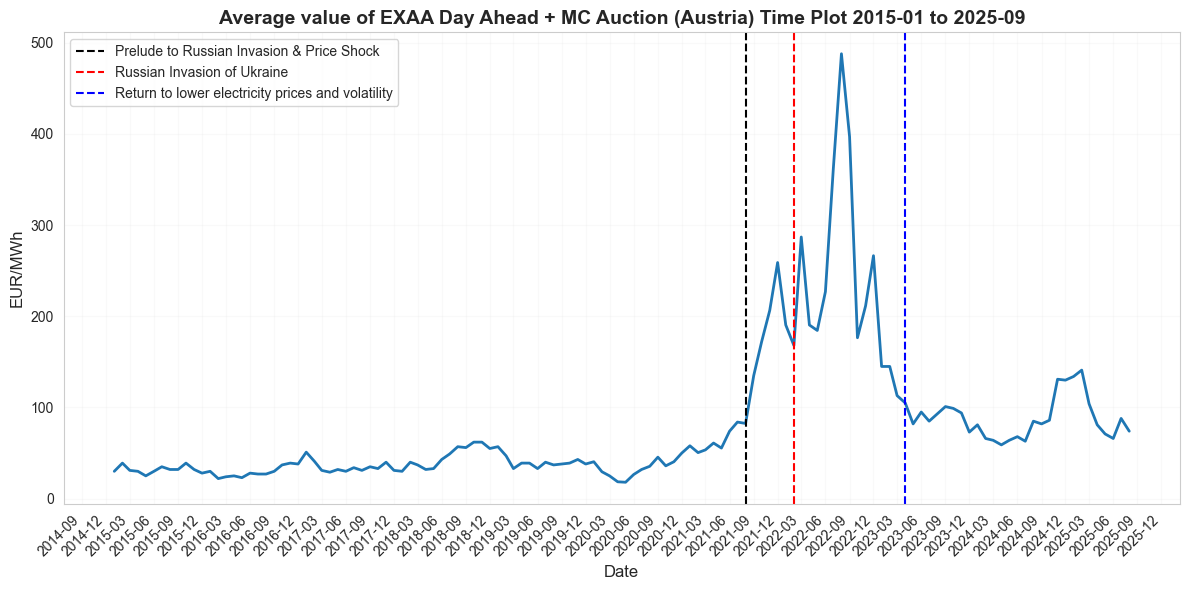


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29


In [142]:
# Average price_combined over main time window
single_plot(df, 'price_combined', all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

##### First Visual analysis of ETS Carbon Allowance Prices
- Correlation with electricity prices: there is a visible, but rought alignment between carbon prices and electricity prices indicating they follow similar regimes
- the drop in carbon prices after the price shock was not as steep as the drop in electricity prices 

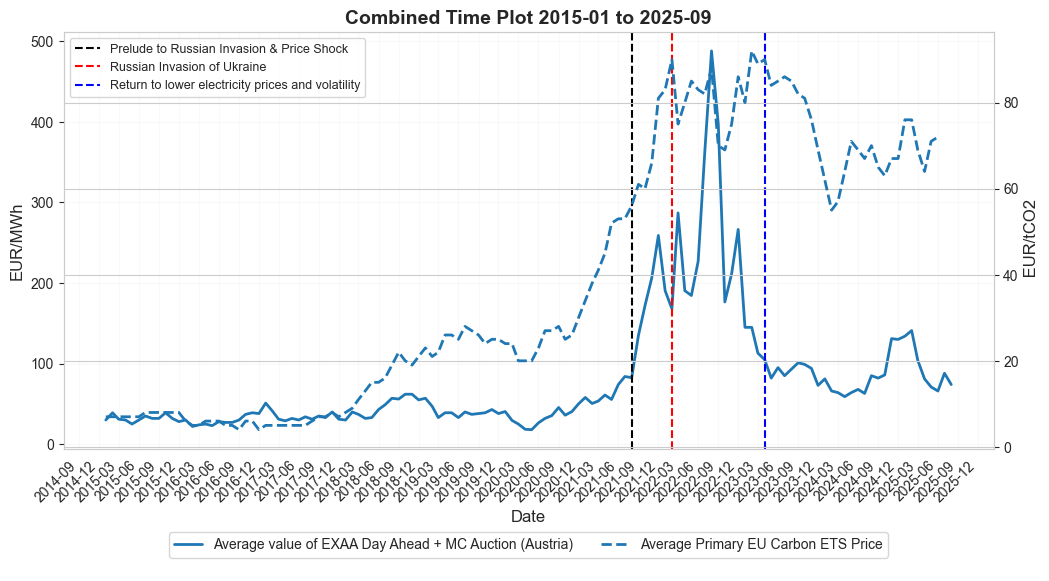


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Average Primary EU Carbon ETS Price
Pre-2021-08: Mean=16.71, Std=12.39, N=79
2021-08 to 2022-02: Mean=67.83, Std=11.44, N=6
2022-02 to 2023-04: Mean=81.71, Std=7.30, N=14
Post-2023-04: Mean=71.96, Std=9.22, N=27



In [143]:

dual_axis_plot(df, ['price_combined'], ['carbonprices_primary_market'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

##### Structural Breaks in the energy market

EDA reveals a clear pattern of structural breaks in the energy market correlated with the price-shock in electricity prices identified above.

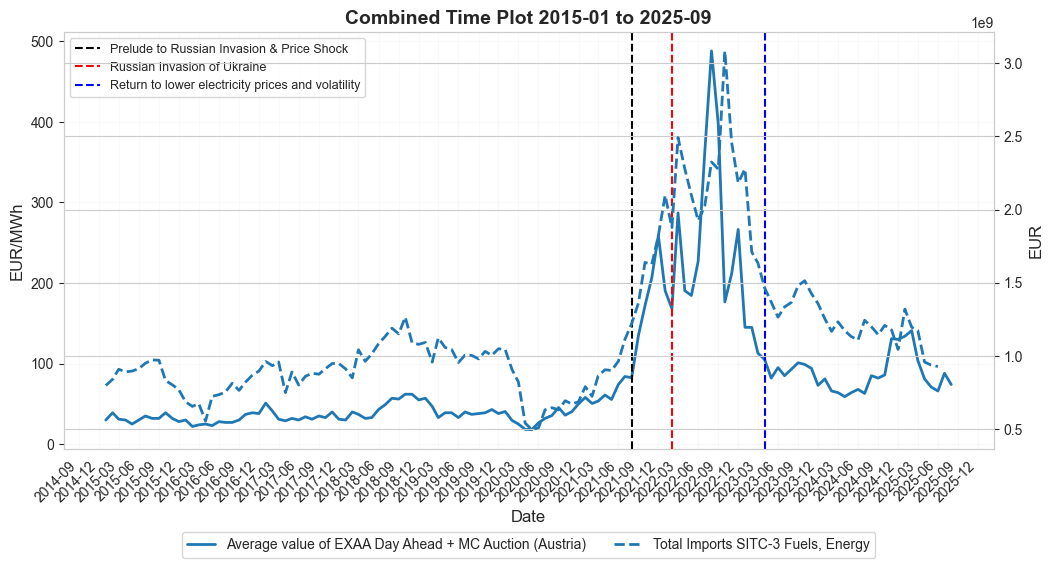


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total Imports SITC-3 Fuels, Energy
Pre-2021-08: Mean=882167807.25, Std=163569202.93, N=79
2021-08 to 2022-02: Mean=1627070355.17, Std=314803627.79, N=6
2022-02 to 2023-04: Mean=2188754168.00, Std=366907088.51, N=14
Post-2023-04: Mean=1227487110.93, Std=157484789.05, N=27



In [144]:
# Energy imports closely mirror / lag electricity prices
dual_axis_plot(df, ['price_combined'], ['econ_imports_energy_EUR'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)




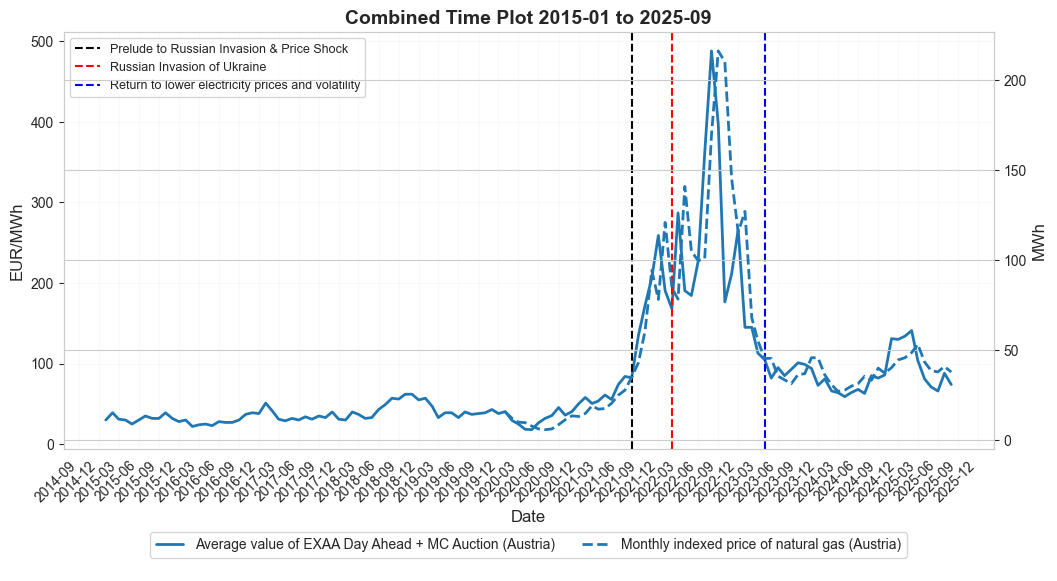


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Monthly indexed price of natural gas (Austria)
Pre-2021-08: Mean=13.89, Std=6.24, N=19
2021-08 to 2022-02: Mean=71.98, Std=32.42, N=6
2022-02 to 2023-04: Mean=122.50, Std=49.38, N=14
Post-2023-04: Mean=38.55, Std=6.56, N=29



In [145]:
# The monthly indexed price of natural gas also shows this pattern
dual_axis_plot(df, ['price_combined'], ['oegpi_month'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



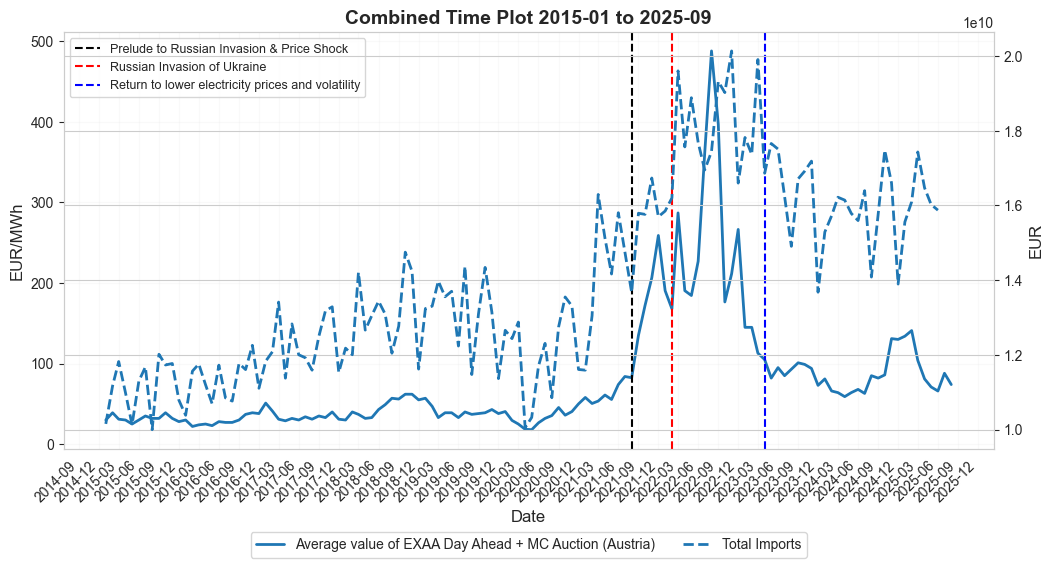


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total Imports
Pre-2021-08: Mean=12352159577.08, Std=1347024924.75, N=79
2021-08 to 2022-02: Mean=15585032755.00, Std=1014251710.39, N=6
2022-02 to 2023-04: Mean=18179722057.79, Std=1277804518.15, N=14
Post-2023-04: Mean=16079055535.04, Std=1060358334.33, N=27



In [146]:
# The development of total imports into austria shows a link to the price shocks
# The pattern somewhat resembles energy imports
dual_axis_plot(df, ['price_combined'], ['econ_imports_total_EUR'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



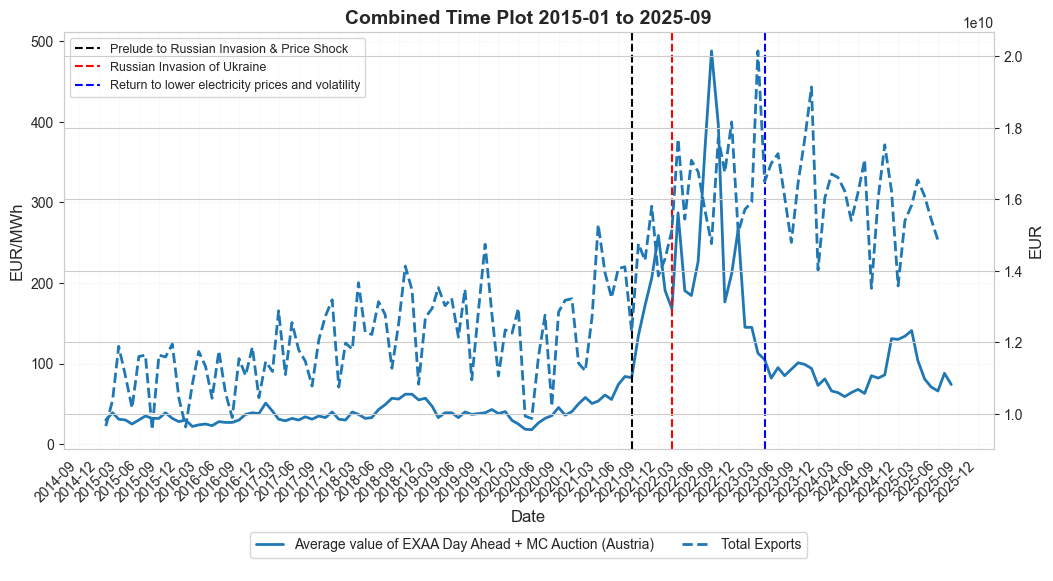


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total Exports
Pre-2021-08: Mean=11966036461.47, Std=1273578155.78, N=79
2021-08 to 2022-02: Mean=14225577149.17, Std=1151187062.21, N=6
2022-02 to 2023-04: Mean=16580763680.93, Std=1491865038.08, N=14
Post-2023-04: Mean=16085781714.33, Std=1244871916.89, N=27



In [147]:
# The development of exports shows a link to the price shocks. Exports seem to have 
# stagnated since the price shock
dual_axis_plot(df, ['price_combined'], ['econ_exports_total_EUR'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



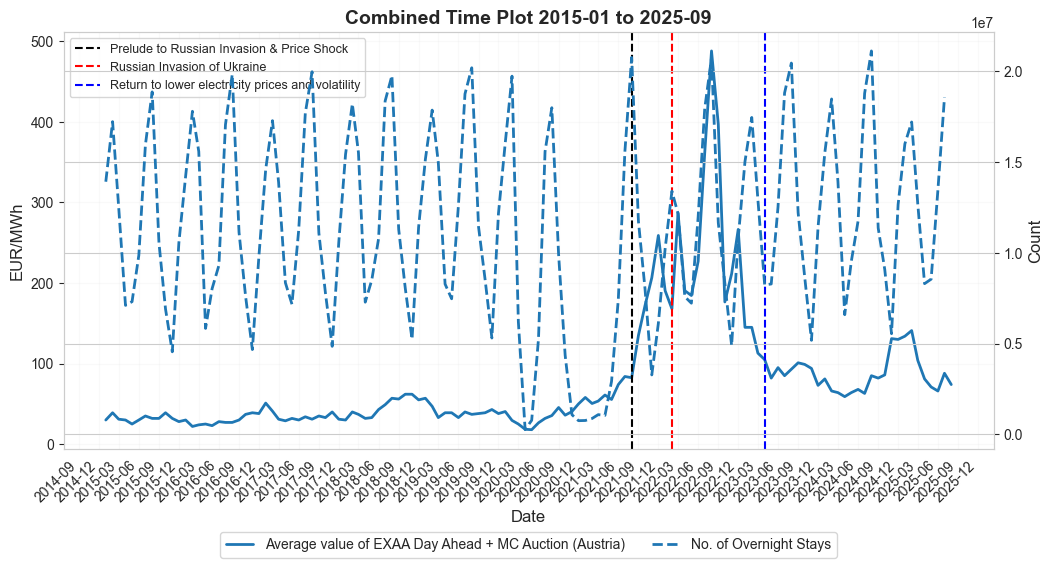


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: No. of Overnight Stays
Pre-2021-08: Mean=10768383.89, Std=5700639.23, N=79
2021-08 to 2022-02: Mean=10018689.17, Std=6054404.47, N=6
2022-02 to 2023-04: Mean=12293870.14, Std=4472930.36, N=14
Post-2023-04: Mean=12672193.93, Std=4634369.84, N=28



In [148]:
# The develpment in tourism, which is an important economic sector in Austria
# shows little apparent correlation with electricity prices.
# The spice coinciding with peak energy prices is likely spurious
# There is a clear seasonal pattern, interrupted by the pandemic (2020-12-2021-06)
dual_axis_plot(df, ['price_combined'], ['econ_count_overnight_stays'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)


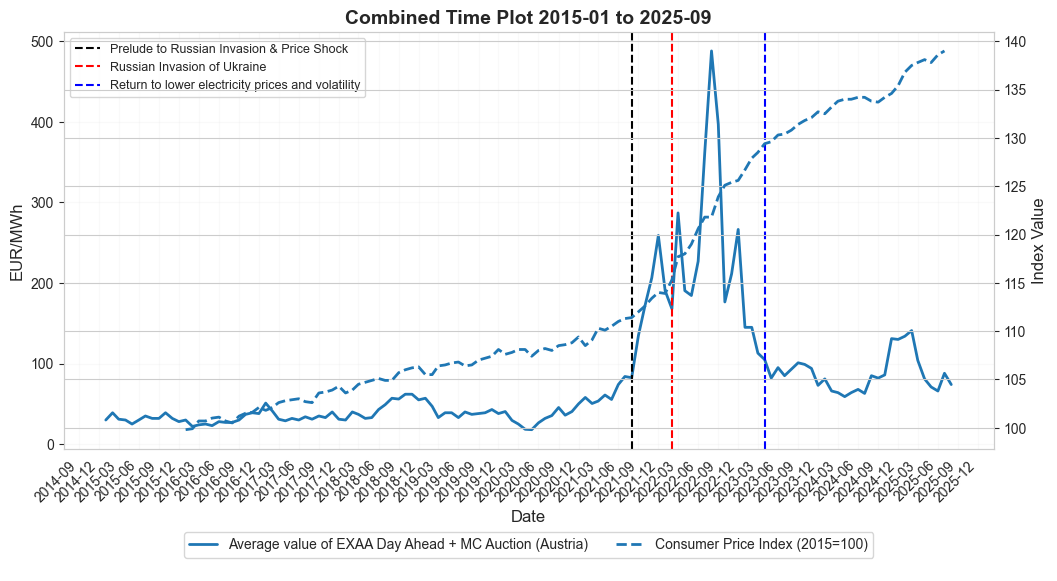


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Consumer Price Index (2015=100)
Pre-2021-08: Mean=105.33, Std=3.06, N=67
2021-08 to 2022-02: Mean=112.88, Std=1.06, N=6
2022-02 to 2023-04: Mean=122.66, Std=4.12, N=14
Post-2023-04: Mean=133.99, Std=2.80, N=28



In [149]:
# Inflation as measured by the 2015 Consumer Price Index 
# has been on the rise every since the start of available data
# However the rate of increase has risen dramatically since the energy price shocks
dual_axis_plot(df, ['price_combined'], ['econ_consumer_price_index'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)


##### First visual analysis of electricity production and consumption: 
Aggregated electricity consumption and production indicators show only some correlation with energy price.
However a closer look at the production statistics a strong rise in photovoltaic and wind production associated with the price shocks, mainly driven by the need to become more independent from russian 

A first visual inspection of aggregated electricity consumption and production reveals:
- Seasonality: strong seasonal component with peaks during the winter. 
- Trend: some upwards trend over time for production, no clear trend for consumption
- Correlation with electricity prices: weak correlation in production


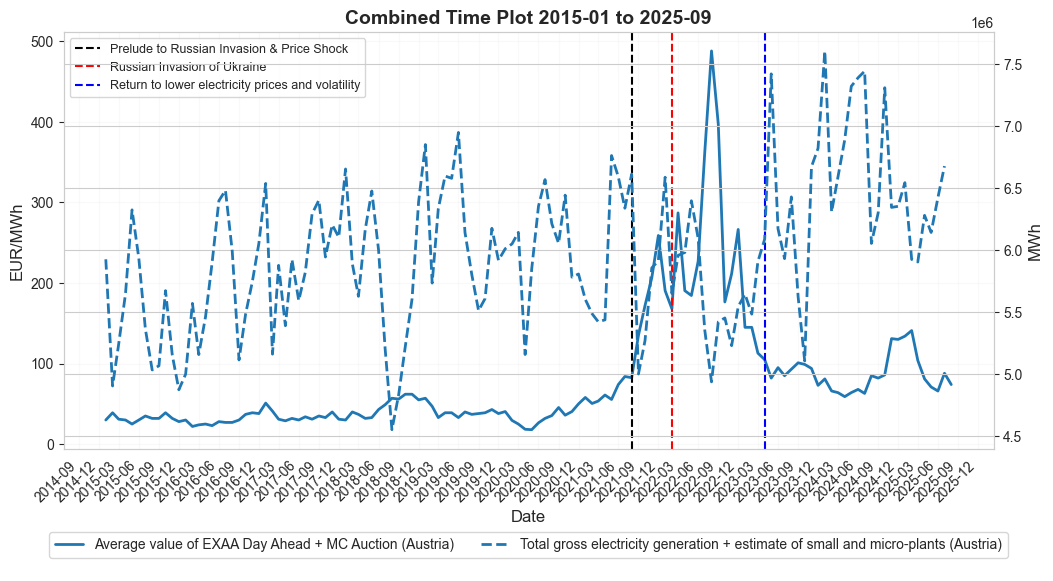


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total gross electricity generation + estimate of small and micro-plants (Austria)
Pre-2021-08: Mean=5842014.84, Std=537136.72, N=79
2021-08 to 2022-02: Mean=5871946.67, Std=661901.64, N=6
2022-02 to 2023-04: Mean=5645048.29, Std=385532.22, N=14
Post-2023-04: Mean=6501614.71, Std=606800.55, N=28



In [150]:
# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['prod_power_production_total'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)


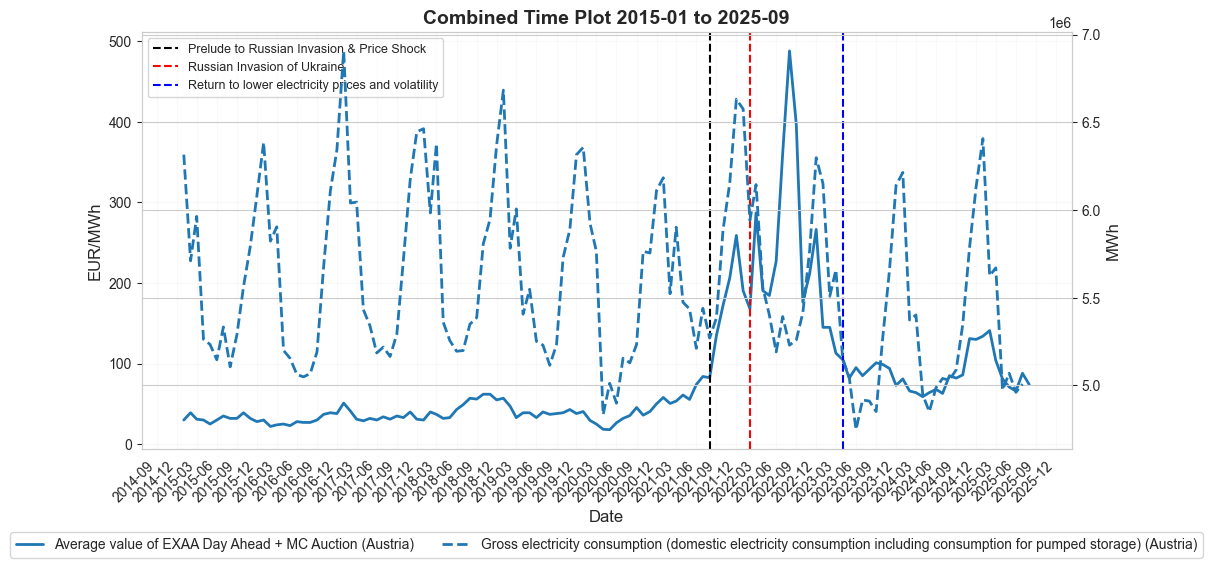


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Gross electricity consumption (domestic electricity consumption including consumption for pumped storage) (Austria)
Pre-2021-08: Mean=5629048.24, Std=476728.56, N=79
2021-08 to 2022-02: Mean=5983728.67, Std=579294.56, N=6
2022-02 to 2023-04: Mean=5636671.29, Std=368513.52, N=14
Post-2023-04: Mean=5307064.86, Std=469037.16, N=28



In [151]:
# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['prod_gross_electricity_consumption'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



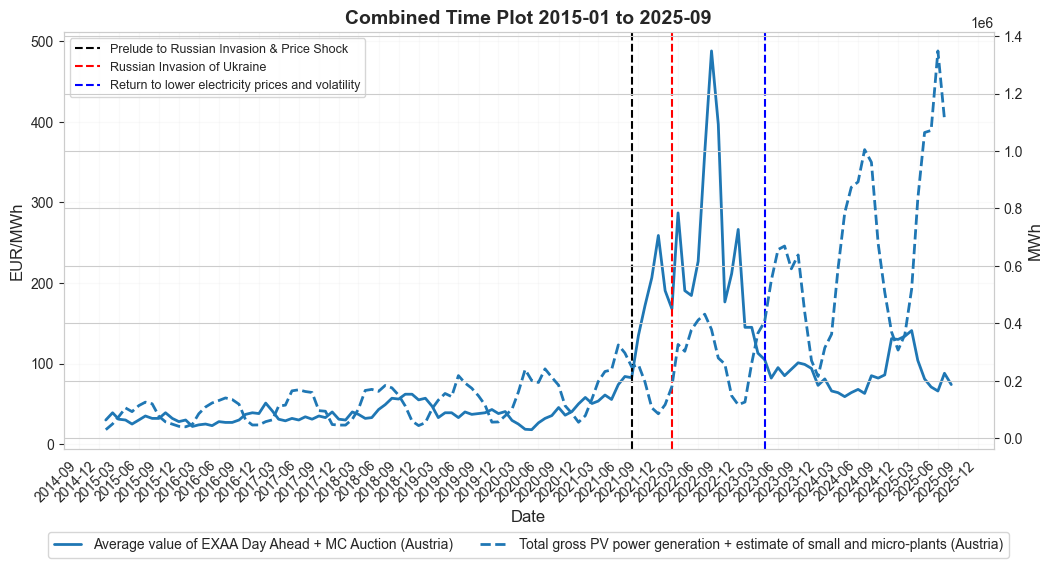


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total gross PV power generation + estimate of small and micro-plants (Austria)
Pre-2021-08: Mean=122594.09, Std=64408.91, N=79
2021-08 to 2022-02: Mean=168165.33, Std=75220.99, N=6
2022-02 to 2023-04: Mean=283251.43, Std=106679.16, N=14
Post-2023-04: Mean=656713.39, Std=297963.99, N=28



In [152]:
#Very strong increase in PV production visibly associated with the price shocks

dual_axis_plot(df, ['price_combined'], ['prod_pv_total'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

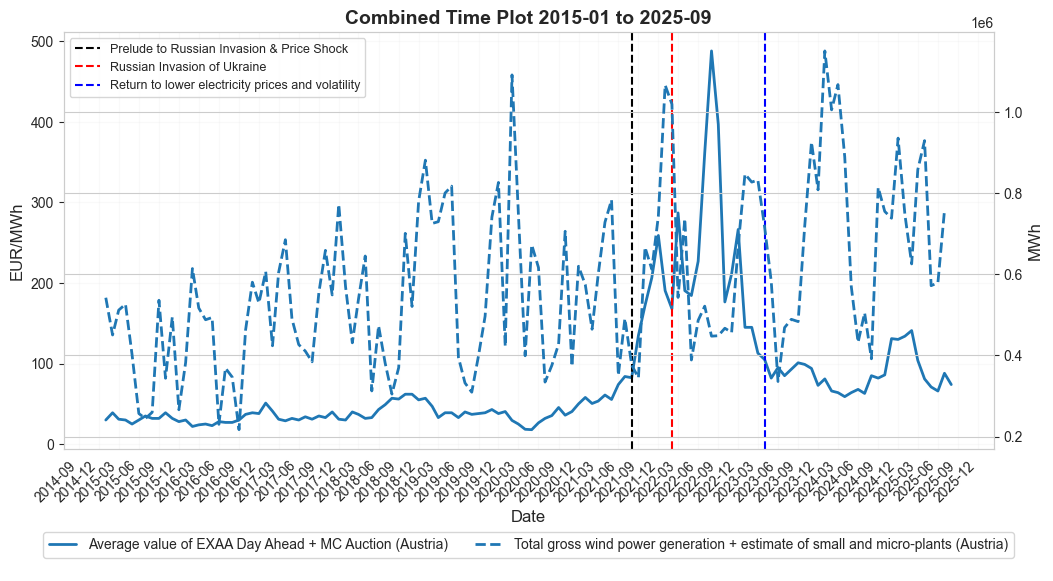


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total gross wind power generation + estimate of small and micro-plants (Austria)
Pre-2021-08: Mean=517807.46, Std=174997.73, N=79
2021-08 to 2022-02: Mean=635185.83, Std=264798.73, N=6
2022-02 to 2023-04: Mean=621115.71, Std=198426.82, N=14
Post-2023-04: Mean=709170.71, Std=213883.72, N=28



In [153]:
#Association of wind production increase with price shocks less clear due to volatility
dual_axis_plot(df, ['price_combined'], ['prod_wind_total'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

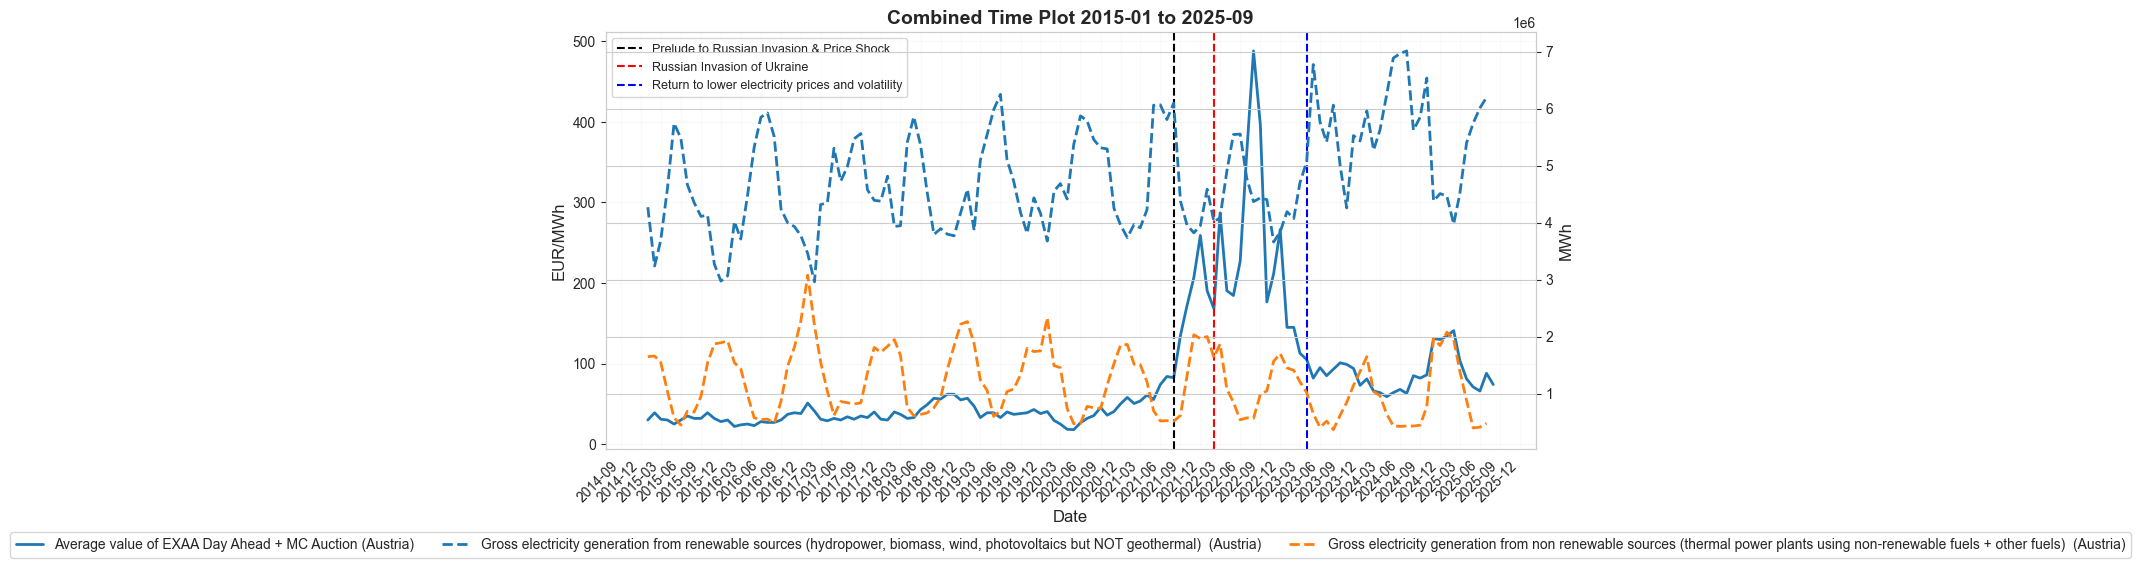


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Gross electricity generation from renewable sources (hydropower, biomass, wind, photovoltaics but NOT geothermal)  (Austria)
Pre-2021-08: Mean=4584323.80, Std=834643.90, N=79
2021-08 to 2022-02: Mean=4463337.67, Std=850610.49, N=6
2022-02 to 2023-04: Mean=4466851.64, Std=576727.41, N=14
Post-2023-04: Mean=5587164.57, Std=852594.25, N=28

REGIME STATISTICS: Gross electricity generation from non renewable sources (thermal power plants using non-renewable fuels + other fuels)  (Austria)
Pre-2021-08: Mean=1254775.92, Std=580290.00, N=79
2021-08 to 2022-02: Mean=1407094.17, Std=704860.29, N=6
2022-02 to 2023-04: Mean=1178196.43, Std=443741.27, N=14
Post-2023-04: Mean=914450.11, Std=554307.04, N=28



In [154]:
# This combined plot shows the production of renewable and non-renewable energy sources over time
# together with electricity prices
# There is little indication for a decrease in non-renewable production
# Renewable production seems to have increased somehwat
dual_axis_plot(df, ['price_combined'], ['prod_renewable', 'prod_non_renewable'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)


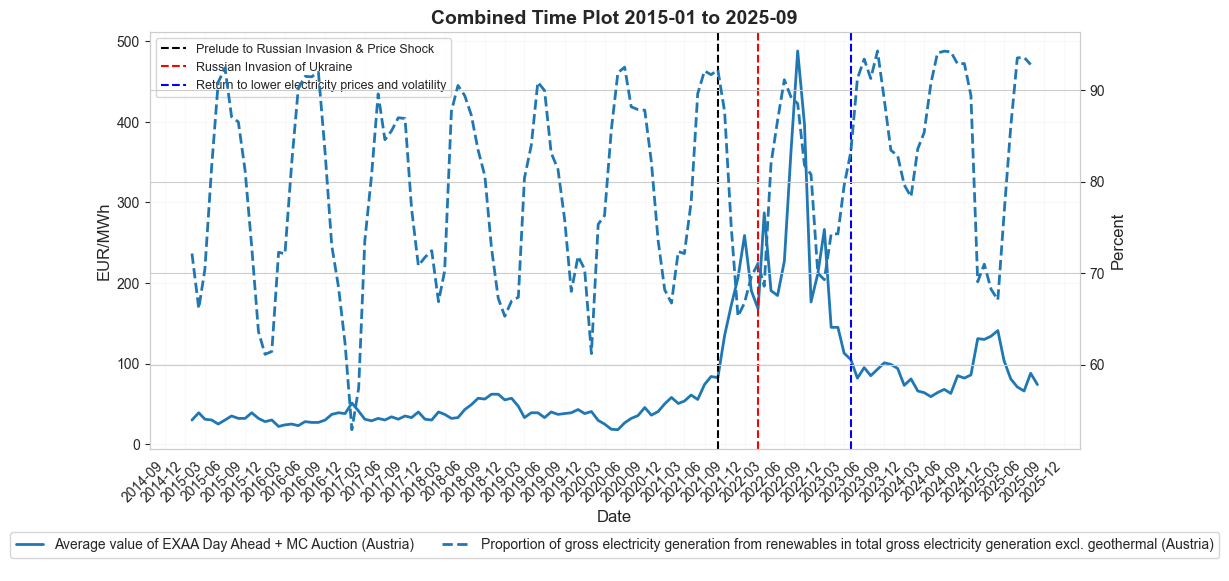


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Proportion of gross electricity generation from renewables in total gross electricity generation excl. geothermal (Austria)
Pre-2021-08: Mean=78.23, Std=10.17, N=79
2021-08 to 2022-02: Mean=76.10, Std=11.31, N=6
2022-02 to 2023-04: Mean=79.08, Std=7.91, N=14
Post-2023-04: Mean=85.77, Std=8.79, N=28



In [155]:
# This plot shows the percentage of renewables in total production
# Renewable energy production has always been strong in Austria, due to its historically
# large capacity for hydro power production
# All in all, the increase in PV and wind productions seems to have only a small effect on the overall
# percentage of renewables in total production
dual_axis_plot(df, ['price_combined'], ['prod_renewables_pct_total'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)


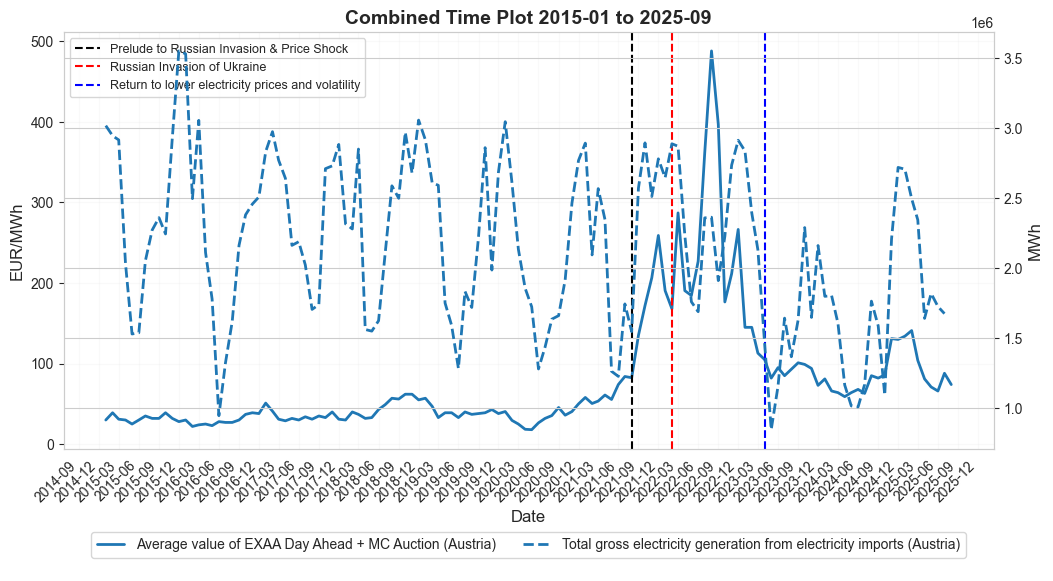


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total gross electricity generation from electricity imports (Austria)
Pre-2021-08: Mean=2251832.75, Std=585634.94, N=79
2021-08 to 2022-02: Mean=2491748.67, Std=484186.57, N=6
2022-02 to 2023-04: Mean=2379397.71, Std=421862.66, N=14
Post-2023-04: Mean=1696977.04, Std=512446.04, N=28



In [156]:
# Electricity imports seem to have somewhat decreased since the price shocks
dual_axis_plot(df, ['price_combined'], ['prod_electricity_imports'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



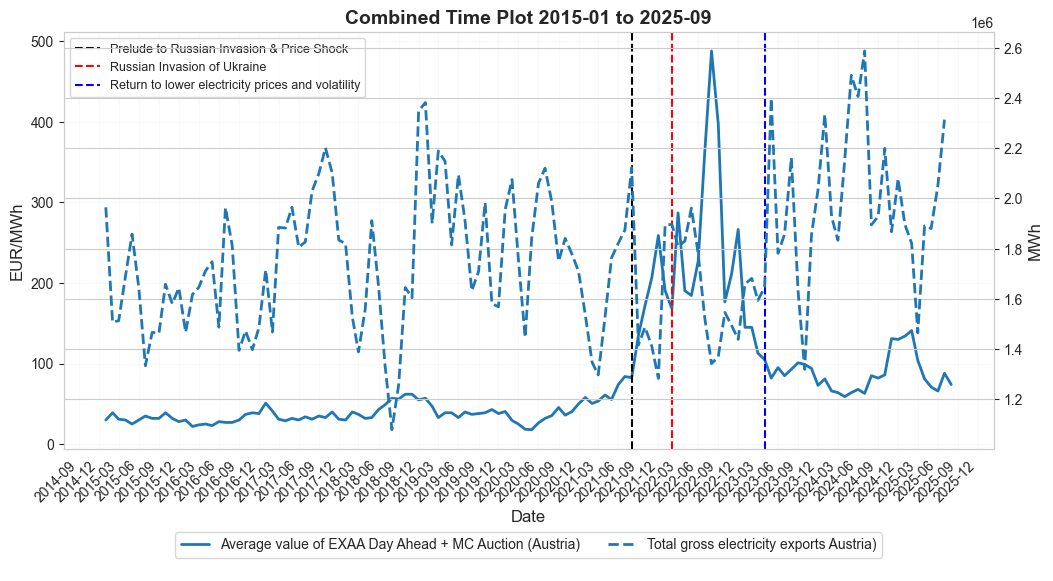


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Total gross electricity exports Austria)
Pre-2021-08: Mean=1732857.33, Std=264867.62, N=79
2021-08 to 2022-02: Mean=1602752.67, Std=328879.16, N=6
2022-02 to 2023-04: Mean=1638010.86, Std=196751.23, N=14
Post-2023-04: Mean=1989629.54, Std=301381.71, N=28



In [157]:
# Electricity exports seem to have somewhat increased since the price shocks
dual_axis_plot(df, ['price_combined'], ['prod_electricity_exports'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



##### First visual analysis of Climate data:

Naturally, climate data shows no direct link to the economic repercussions of the energy price shocks.

A first rough visual analysis shows the following patterns:
- Seasonality: as expected there is a strong seasonal component to both heating and cooling days
- Trend: the peak number of heating days in austria has increased noticably in the duration covered by the plot
- the peak number of cooling days exhibits a much less clear trend
- the indicated trend in heating and cooling days is less clear for europe as a whole due to the different climatic conditions all over the EU  
- Correlation with electricity prices: no visible correlation

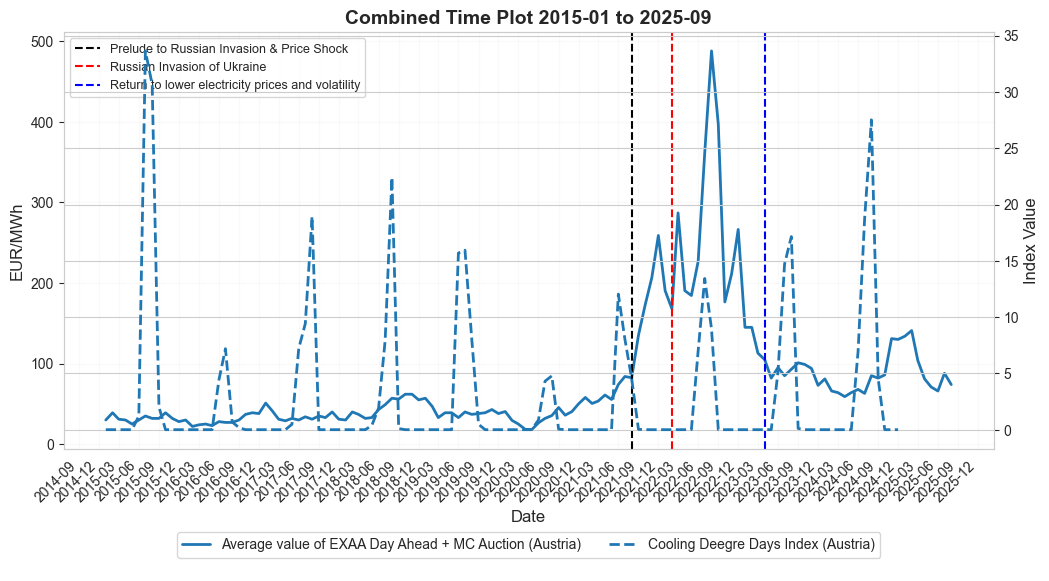


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Cooling Deegre Days Index (Austria)
Pre-2021-08: Mean=2.77, Std=6.63, N=79
2021-08 to 2022-02: Mean=0.76, Std=1.85, N=6
2022-02 to 2023-04: Mean=2.10, Std=4.37, N=14
Post-2023-04: Mean=4.52, Std=8.02, N=21



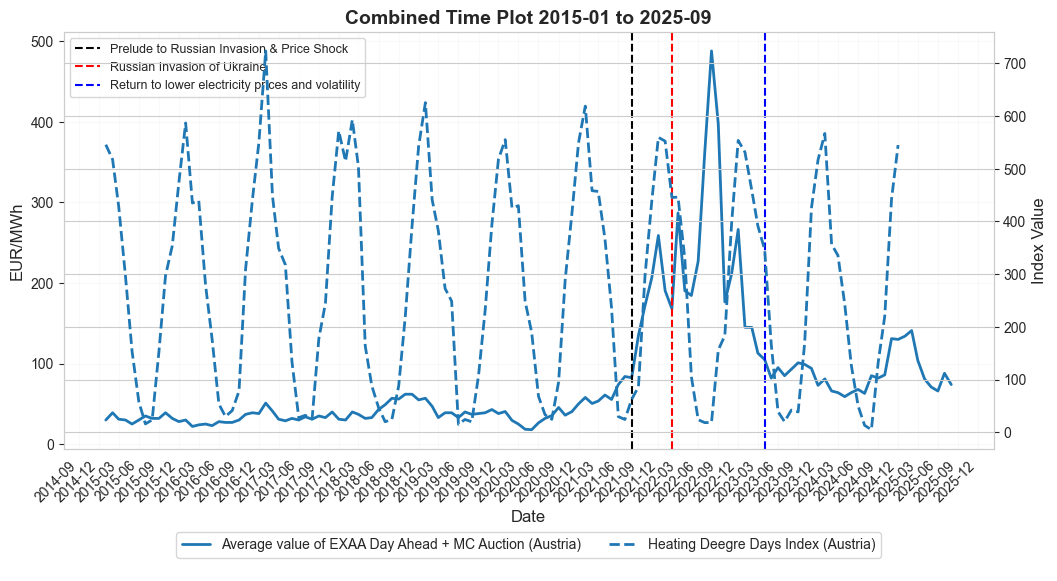


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Heating Deegre Days Index (Austria)
Pre-2021-08: Mean=281.26, Std=202.73, N=79
2021-08 to 2022-02: Mean=332.60, Std=221.82, N=6
2022-02 to 2023-04: Mean=289.87, Std=198.04, N=14
Post-2023-04: Mean=228.74, Std=190.96, N=21



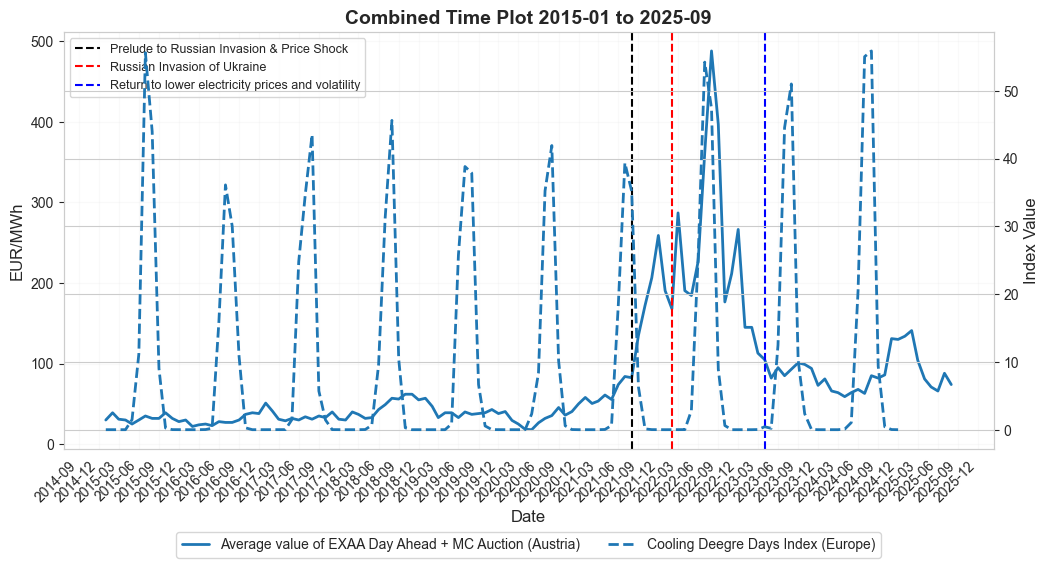


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Cooling Deegre Days Index (Europe)
Pre-2021-08: Mean=8.77, Std=14.97, N=79
2021-08 to 2022-02: Mean=6.94, Std=14.07, N=6
2022-02 to 2023-04: Mean=9.97, Std=18.69, N=14
Post-2023-04: Mean=12.57, Std=20.26, N=21



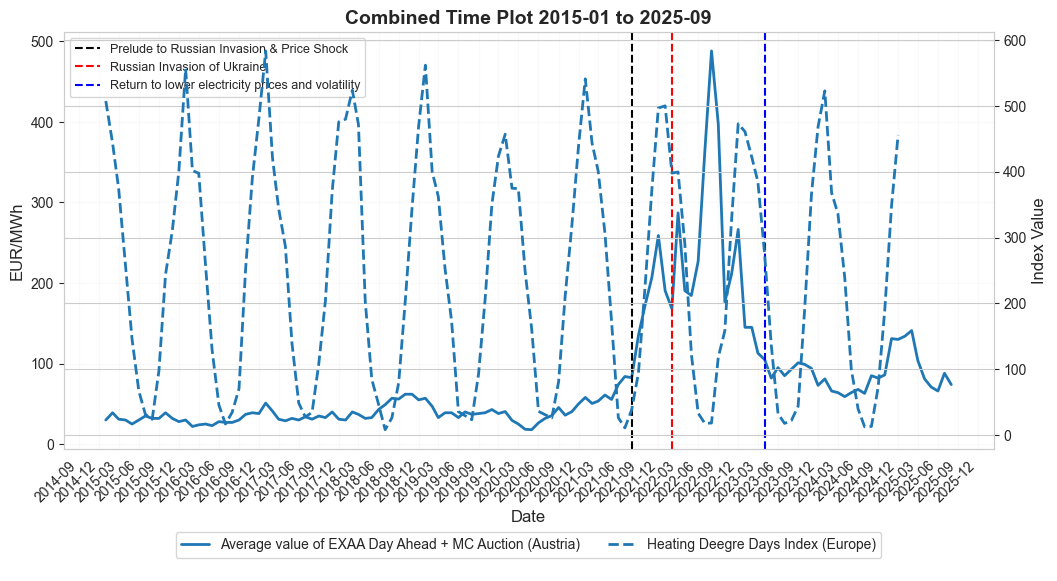


REGIME STATISTICS: Average value of EXAA Day Ahead + MC Auction (Austria)
Pre-2021-08: Mean=38.28, Std=12.34, N=79
2021-08 to 2022-02: Mean=174.25, Std=60.75, N=6
2022-02 to 2023-04: Mean=240.07, Std=108.75, N=14
Post-2023-04: Mean=88.45, Std=22.65, N=29

REGIME STATISTICS: Heating Deegre Days Index (Europe)
Pre-2021-08: Mean=246.71, Std=177.25, N=79
2021-08 to 2022-02: Mean=287.50, Std=199.62, N=6
2022-02 to 2023-04: Mean=258.96, Std=173.01, N=14
Post-2023-04: Mean=202.44, Std=171.39, N=21



In [158]:
# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['climate_cdd_at'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['climate_hdd_at'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['climate_cdd_eu'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)

# Dual axis plot
dual_axis_plot(df, ['price_combined'], ['climate_hdd_eu'],
               all, 'monthly', meta_lib_path, regime_breaks=regime_breaks)



#### Conclusions for modelling purposes so far

- The structural break in the price regime will be adressed during modelling. For the purposes of simplicity, an approach using dummy variables to indicate the price-regimes will be used first.

- The most important variables for price prognostics are expected to be
	1. Gas prices
	2. Carbon prices
	3. Energy imports

- From this analysis, very little impact is expected from the amount of renewable energy produced or the proportion of renewable energy in the total mix



### Formal time-series decomposition of energy prices

Before modelling, a time-series decomposition will is conducted to analyse the signal components within `price_combined`:
- Trend
- Seasonality
- Autocorrelation
- Residuals

In [159]:
#Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

df_monthly = df[df['aggregation_level'] == 'monthly'].copy()
df_monthly = df_monthly.set_index('date_dt') 

#### Determination of additive or multiplicative models

In [160]:
import numpy as np
import pandas as pd

print("="*70)
print("PREPARATION FOR TIME SERIES-DECOMPOSITION")
print("="*70)

# Prepare series
y = df_monthly['price_combined'].dropna()

print(f"\nInput Series:")
print(f"  Period: {y.index[0]} to {y.index[-1]}")
print(f"  Observations: {len(y)}")
print(f"  Mean: {y.mean():.2f} EUR/MWh")
print(f"  Std Dev: {y.std():.2f} EUR/MWh")
print(f"  Min: {y.min():.2f} EUR/MWh")
print(f"  Max: {y.max():.2f} EUR/MWh")

# Check if multiplicative model is possible
# Multiplicative requires all positive values
print("")
print(f"Minimum value is {(y.min())} EUR/MWh, multiplicative decomposition is possible.")


PREPARATION FOR TIME SERIES-DECOMPOSITION

Input Series:
  Period: 2015-01-01 00:00:00 to 2025-08-01 00:00:00
  Observations: 128
  Mean: 78.09 EUR/MWh
  Std Dev: 76.83 EUR/MWh
  Min: 18.00 EUR/MWh
  Max: 488.00 EUR/MWh

Minimum value is 18.0 EUR/MWh, multiplicative decomposition is possible.


In [161]:
#additive decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

print("Performing ADDITIVE decomposition...")

decomposition_add = seasonal_decompose(y, 
                                       model='additive', 
                                       period=12, 
                                       extrapolate_trend='freq')

resid_add = decomposition_add.resid.dropna()

print(f"✓ Additive model complete")
print(f"  Residual Std Dev: {resid_add.std():.4f}")

Performing ADDITIVE decomposition...
✓ Additive model complete
  Residual Std Dev: 31.6943


In [162]:
# multiplicative decomposition
print("Performing MULTIPLICATIVE decomposition...")

decomposition_mult = seasonal_decompose(y, 
                                        model='multiplicative', 
                                        period=12, 
                                        extrapolate_trend='freq')

resid_mult = decomposition_mult.resid.dropna()

print(f"✓ Multiplicative model complete")
print(f"  Residual Std Dev: {resid_mult.std():.4f}")

Performing MULTIPLICATIVE decomposition...
✓ Multiplicative model complete
  Residual Std Dev: 0.1746


The much smaller Std Deviation of 0.1746 for the muliplicative model suggests that variabllity is not constant but increases with the data´s level. This is reflected in the visual analysis.

#### Overview

The following code shows an overview of trend, seasonality and residuals for the complete period 2015-2025

- The change in trend due to the price shock is clearly visible, also a positive trend overall
- Substantial seasonal patterns are visible, total influence in explaining variance is to be determined
- The Residual component seens mostly random, with large hetereoscedasticity (up to x1,8 multiplication of price) around the period of the price-shock.

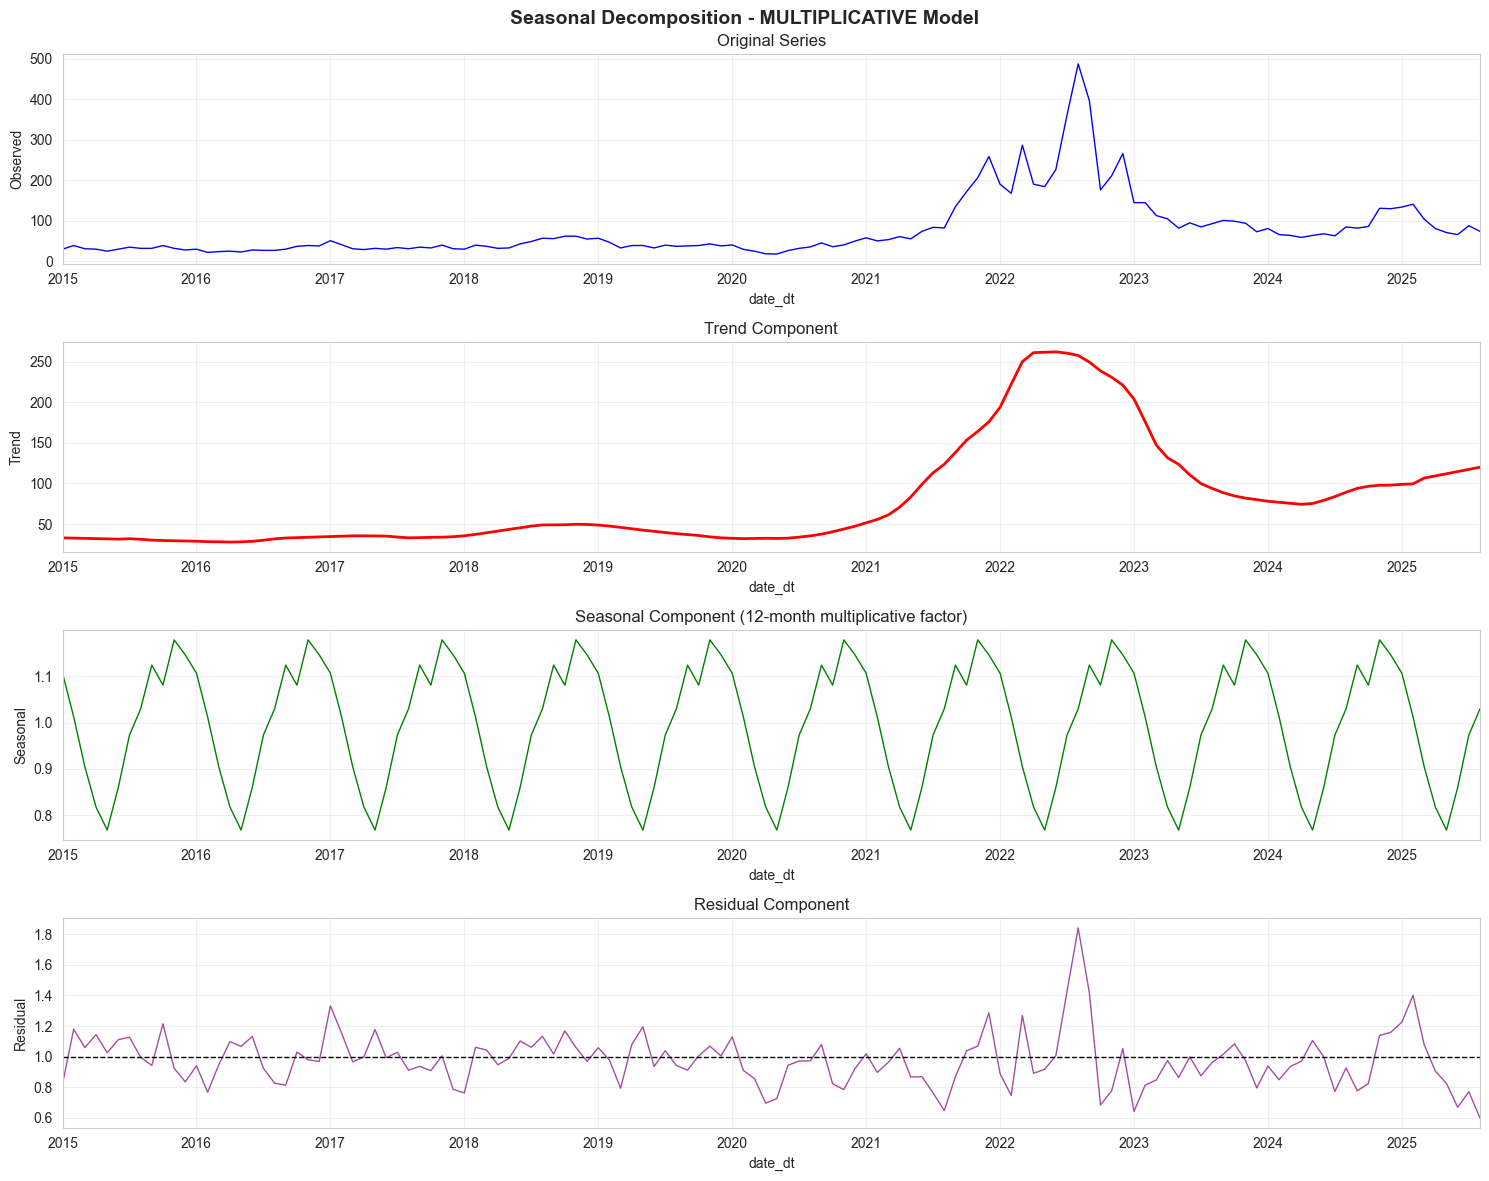

In [163]:
# Visualisation
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('Seasonal Decomposition - MULTIPLICATIVE Model', 
             fontsize=14, fontweight='bold')

# Observed
decomposition_mult.observed.plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_ylabel('Observed')
axes[0].set_title('Original Series')
axes[0].grid(alpha=0.3)

# Trend
decomposition_mult.trend.plot(ax=axes[1], color='red', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component')
axes[1].grid(alpha=0.3)

# Seasonal
decomposition_mult.seasonal.plot(ax=axes[2], color='green', linewidth=1)
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Seasonal Component (12-month multiplicative factor)')
axes[2].grid(alpha=0.3)

# Residual
decomposition_mult.resid.plot(ax=axes[3], color='purple', linewidth=1, alpha=0.7)
axes[3].axhline(1, color='black', linestyle='--', linewidth=1)  # 1.0 for multiplicative
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual Component')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Trend analysis

The linear trend is positive, but in and of itself only explains 36% variance. The price shock most likely plays an important role here.


In [164]:
#Trend analysis - linear regression

from scipy.stats import linregress
import numpy as np

print("="*70)
print("TREND ANALYSIS")
print("="*70)

# Extract trend component
trend = decomposition_mult.trend.dropna()

# Linear regression on trend
x = np.arange(len(trend))
slope, intercept, r_value, p_value, std_err = linregress(x, trend)

print(f"\nLinear Trend Statistics:")
print(f"  Slope: {slope:.4f} EUR/MWh per month")
print(f"  Annual change: {slope * 12:.2f} EUR/MWh per year")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  → Trend is {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")

# Fitted values
fitted_trend = intercept + slope * x

TREND ANALYSIS

Linear Trend Statistics:
  Slope: 1.0524 EUR/MWh per month
  Annual change: 12.63 EUR/MWh per year
  R-squared: 0.3608
  p-value: 0.000000
  → Trend is SIGNIFICANT (α=0.05)


The following visualisation illustrates the significance of the price shock further. It also suggests that the upwards trend that was present before the price shock seems to continue after the price shock.

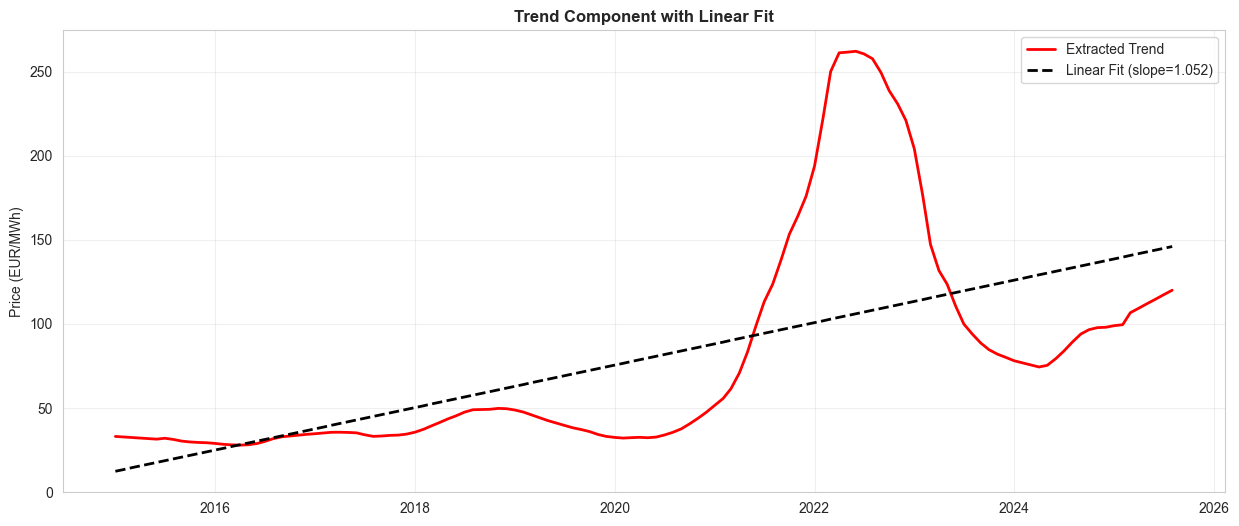

In [165]:
# Plot trend with linear fit and detrended series
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# Plot 1: Trend with linear fit
ax.plot(trend.index, trend.values, label='Extracted Trend', 
             linewidth=2, color='red')
ax.plot(trend.index, fitted_trend, '--', color='black', 
             label=f'Linear Fit (slope={slope:.3f})', linewidth=2)
ax.set_title('Trend Component with Linear Fit', fontweight='bold')
ax.set_ylabel('Price (EUR/MWh)')
ax.legend()
ax.grid(alpha=0.3)



#### Seasonality Analysis
Initial seasonality analysis shows some variation (from slightly below x0.8 to x slightly above 1.1). The box plot medians show that seasonality is slight, but present, with lows in late spring/early summer and highs in late summer through winter. However, there are significant outliers present for the months of march to september which is likely due to the price shocks. Therefore the means are not interpreted here, since they are visibly influenced by the outliers.

C:\Users\paulr\AppData\Local\Temp\ipykernel_17168\1431062317.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_prices, labels=month_labels,


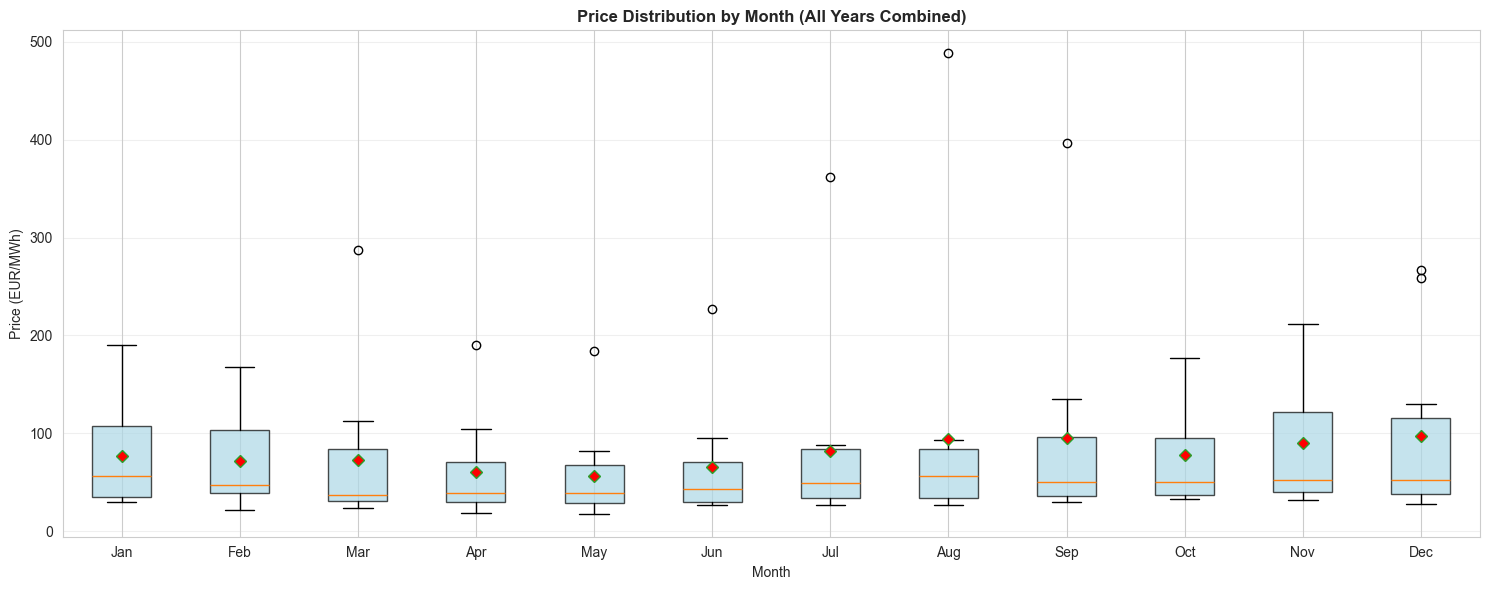

In [166]:
#Seasonality analysis - Boxplot
import matplotlib.pyplot as plt


month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Boxplot: Price distribution by month (all years combined)
fig, ax = plt.subplots(figsize=(15, 6))

monthly_prices = [y[y.index.month == m].values for m in range(1, 13)]
bp = ax.boxplot(monthly_prices, labels=month_labels,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

# Color boxes
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_title('Price Distribution by Month (All Years Combined)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_xlabel('Month')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The monthly patterns for all years support the conclusion that there is some seasonality. Also the lines "pink" for 2021, "black" for 2022 and "gold" for 2023 show the price shock in more detail.

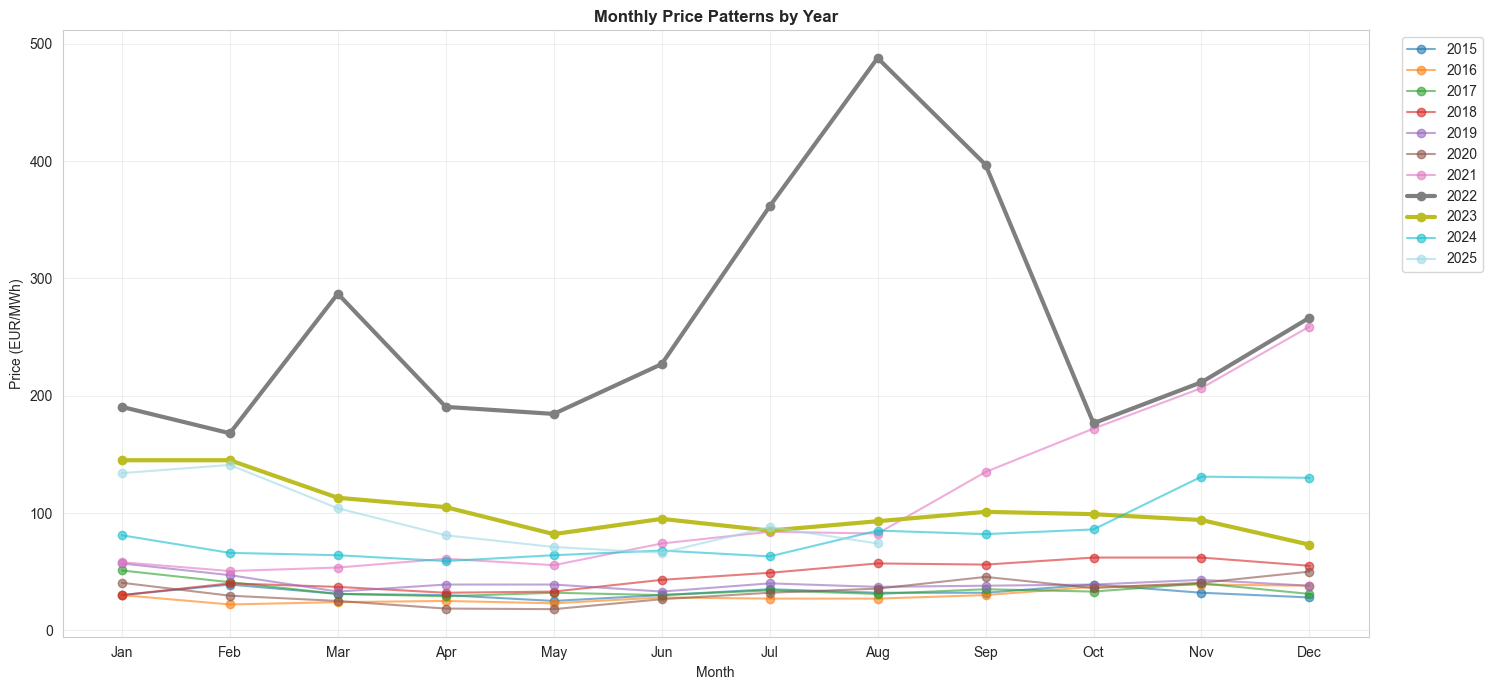

In [167]:
# Seasonality analysis - Monthly patterns by year

fig, ax = plt.subplots(figsize=(15, 7))

years = sorted(y.index.year.unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(years)))

for year, color in zip(years, colors):
    year_data = y[y.index.year == year]
    monthly_avg = year_data.groupby(year_data.index.month).mean()
    
    # Highlight shock years
    linewidth = 3 if year in [2022, 2023] else 1.5
    alpha = 1.0 if year in [2022, 2023] else 0.6
    
    ax.plot(monthly_avg.index, monthly_avg.values, 
            marker='o', label=str(year), color=color, 
            linewidth=linewidth, markersize=6, alpha=alpha)

ax.set_xlabel('Month')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Monthly Price Patterns by Year', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

0.3647 variance in the detrended series is explained by seasonality, the rest is random noise. This is a medium score. High prices occur in december, low prices in late spring. 
Further investigation into seasonality is conducted to see how it changed before and after the price shock, namely a comparison between the pre- and post-shock periods. Results further below.

In [168]:
# Monthly statistics and seasonal strength
import pandas as pd

print("\n" + "="*70)
print("MONTHLY PRICE STATISTICS (ALL YEARS)")
print("="*70)

monthly_stats = pd.DataFrame({
    'Mean': y.groupby(y.index.month).mean(),
    'Std': y.groupby(y.index.month).std(),
    'Min': y.groupby(y.index.month).min(),
    'Max': y.groupby(y.index.month).max()
})
monthly_stats.index = month_labels

print(monthly_stats.round(2).to_string())

# Seasonal strength from decomposition
seasonal_strength = 1 - (decomposition_mult.resid.var() / 
                         (decomposition_mult.seasonal * decomposition_mult.resid).var())

print("\n" + "="*70)
print("SEASONAL PATTERN SUMMARY")
print("="*70)

highest_month = monthly_stats['Mean'].idxmax()
lowest_month = monthly_stats['Mean'].idxmin()

print(f"Highest average month: {highest_month} ({monthly_stats.loc[highest_month, 'Mean']:.2f} EUR/MWh)")
print(f"Lowest average month: {lowest_month} ({monthly_stats.loc[lowest_month, 'Mean']:.2f} EUR/MWh)")
print(f"Range: {monthly_stats['Mean'].max() - monthly_stats['Mean'].min():.2f} EUR/MWh")
print(f"\nSeasonal Strength: {seasonal_strength:.4f}")
print(f"→ Seasonality is {'STRONG' if seasonal_strength > 0.6 else 'MODERATE' if seasonal_strength > 0.3 else 'WEAK'}")


MONTHLY PRICE STATISTICS (ALL YEARS)
      Mean     Std   Min    Max
Jan  77.00   54.92  30.0  190.5
Feb  71.73   52.73  22.0  168.0
Mar  72.95   77.43  24.0  287.0
Apr  60.91   50.52  18.5  190.5
May  57.00   47.28  18.0  184.5
Jun  65.50   58.35  26.5  227.0
Jul  81.68   95.61  27.0  361.5
Aug  94.73  132.74  27.0  488.0
Sep  95.15  111.57  30.0  397.0
Oct  77.95   55.59  33.0  176.5
Nov  89.95   69.87  32.0  211.5
Dec  96.85   92.31  28.0  266.5

SEASONAL PATTERN SUMMARY
Highest average month: Dec (96.85 EUR/MWh)
Lowest average month: May (57.00 EUR/MWh)
Range: 39.85 EUR/MWh

Seasonal Strength: 0.3647
→ Seasonality is MODERATE


In [169]:
#Seasonality strenght pre-shock
y_pre = y.loc[:'2021-09'] #configure for pre-shock period

print("\n" + "="*70)
print("SEASONAL STRENGTH - FULL PERIOD VS PRE-SHOCK COMPARISON")
print("="*70)

# Full period (already calculated)
seasonal_strength_full = 0.3647
print(f"\nComplete Period (2015-2025):")
print(f"  Seasonal Strength: {seasonal_strength_full:.4f} (MODERATE)")

print(f"\nPost-Shock Period (2023-04 onwards):")
print(f"  Observations: {len(y_post)} months")

# Decompose post-shock period
decomp_pre = seasonal_decompose(y_pre, model='multiplicative', 
                                 period=12, extrapolate_trend='freq')

# Calculate seasonal strength
seasonal_strength_pre = 1 - (decomp_pre.resid.var() / 
                              (decomp_pre.seasonal * decomp_pre.resid).var())

print(f"  Seasonal Strength: {seasonal_strength_pre:.4f}")
print(f"  → {'STRONG' if seasonal_strength_pre > 0.6 else 'MODERATE' if seasonal_strength_pre > 0.3 else 'WEAK'}")


print("="*70)
print(f"\nChange: {seasonal_strength_pre - seasonal_strength_full:+.4f}")


SEASONAL STRENGTH - FULL PERIOD VS PRE-SHOCK COMPARISON

Complete Period (2015-2025):
  Seasonal Strength: 0.3647 (MODERATE)

Post-Shock Period (2023-04 onwards):
  Observations: 29 months
  Seasonal Strength: 0.3992
  → MODERATE

Change: +0.0345


In [174]:
#Seasonality strenght post-shock
y_post = y.loc['2023-04':] #configure for post-shock period

print("\n" + "="*70)
print("SEASONAL STRENGTH - FULL PERIOD VS POST-SHOCK COMPARISON")
print("="*70)

# Full period (already calculated)
seasonal_strength_full = 0.3647
print(f"\nComplete Period:")
print(f"  Seasonal Strength: {seasonal_strength_full:.4f} (MODERATE)")

# Post-shock period only
y_post = y.loc['2023-04':]

print(f"\nPost-Shock Period (2023-04 onwards):")
print(f"  Observations: {len(y_post)} months")

# Decompose post-shock period
decomp_post = seasonal_decompose(y_post, model='multiplicative', 
                                 period=12, extrapolate_trend='freq')

# Calculate seasonal strength
seasonal_strength_post = 1 - (decomp_post.resid.var() / 
                              (decomp_post.seasonal * decomp_post.resid).var())

print(f"  Seasonal Strength: {seasonal_strength_post:.4f}")
print(f"  → {'STRONG' if seasonal_strength_post > 0.6 else 'MODERATE' if seasonal_strength_post > 0.3 else 'WEAK'}")


print("="*70)
print(f"\nChange: {seasonal_strength_post - seasonal_strength_full:+.4f}")


SEASONAL STRENGTH - FULL PERIOD VS POST-SHOCK COMPARISON

Complete Period:
  Seasonal Strength: 0.3647 (MODERATE)

Post-Shock Period (2023-04 onwards):
  Observations: 29 months
  Seasonal Strength: 0.1646
  → WEAK

Change: -0.2001


In [171]:
# Compare all periods
print("\n" + "="*70)
print("SEASONAL STRENGTH SUMMARY - PRE AND POST-SHOCK")
print("="*70)
print(f"Pre-Shock (2015-2021):  {seasonal_strength_pre:.4f} (MODERATE)")
print(f"Post-Shock (2023-2025):  {seasonal_strength_post:.4f} (WEAK)")

print(f"\nInterpretation:")
print(f"  Pre-Shock has STRONGEST seasonality ({seasonal_strength_pre:.4f})")
print(f"  Price shock weakens apparent seasonality")
print(f"  Post-Shock shows weakest seasonality ({seasonal_strength_post:.4f})")
print("="*70)


SEASONAL STRENGTH SUMMARY - PRE AND POST-SHOCK
Pre-Shock (2015-2021):  0.3992 (MODERATE)
Post-Shock (2023-2025):  0.1646 (WEAK)

Interpretation:
  Pre-Shock has STRONGEST seasonality (0.3992)
  Price shock weakens apparent seasonality
  Post-Shock shows weakest seasonality (0.1646)


Seasonality before the price-shocks was actually stronger than afterwards. This may be due to new market dynamics, but it may also be an artifact of having only 2 years for seasonality analysis post-shock.

#### Autocorrelation analysis

Autocorrelation analysis reveals a gradual decline and lag almost 7 months back.

Partial autocorrelation is very high at lag 1 and shows spikes at 3, 6, 9 and 12, further confirming seasonal patterns, which have been detected earlier.

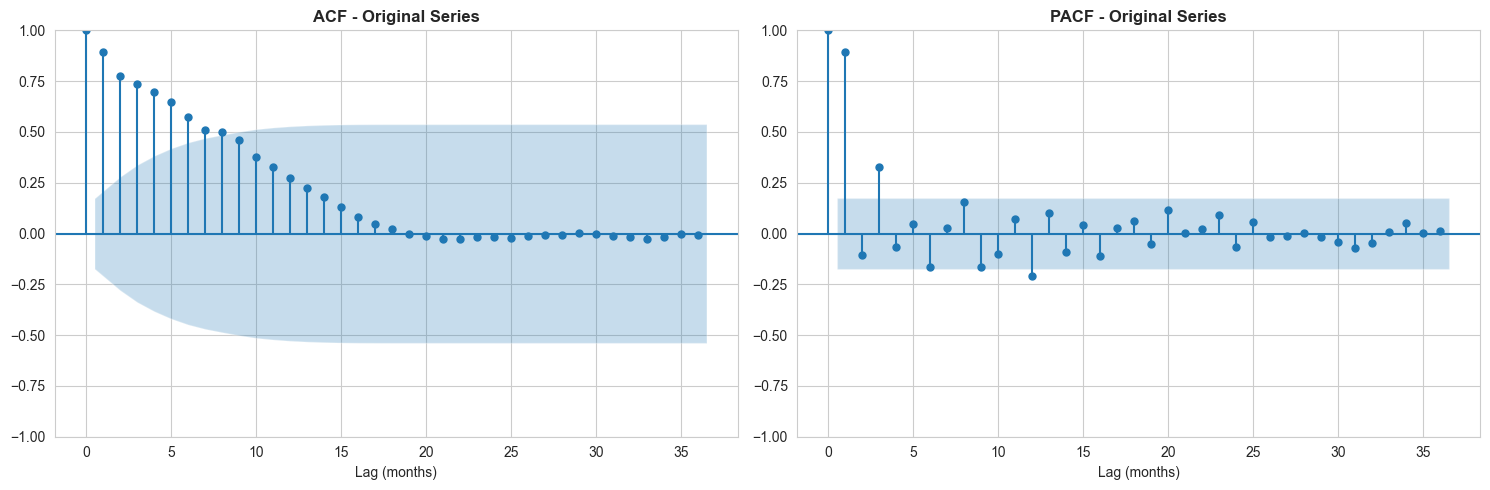


Interpretation Guide:
  ACF: Shows correlation between t and t-k
  PACF: Shows direct correlation after removing intermediate lags
  Significant spikes (outside blue area) indicate autocorrelation


In [172]:
# autocorrelation analysis - ACF & PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF
plot_acf(y, lags=36, ax=axes[0])
axes[0].set_title('ACF - Original Series', fontweight='bold')
axes[0].set_xlabel('Lag (months)')

# PACF
plot_pacf(y, lags=36, ax=axes[1])
axes[1].set_title('PACF - Original Series', fontweight='bold')
axes[1].set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

print("\nInterpretation Guide:")
print("  ACF: Shows correlation between t and t-k")
print("  PACF: Shows direct correlation after removing intermediate lags")
print("  Significant spikes (outside blue area) indicate autocorrelation")

In [173]:
import numpy as np

# Calculate ACF and PACF values
acf_values = acf(y, nlags=18)
pacf_values = pacf(y, nlags=18)

# Calculate significance threshold
n = len(y)
threshold_95 = 1.96 / np.sqrt(n)

print(f"\nSignificance threshold (95%): ±{threshold_95:.4f}")
print(f"(Based on n={n} observations)")

# Print PACF with exact threshold
print("\n" + "="*70)
print("PACF Values (Lags 0-18):")
print("Lag | PACF    | Significant?")
print("-" * 40)
for lag, val in enumerate(pacf_values):
    significance = "***" if abs(val) > threshold_95 else ""
    print(f"{lag:3d} | {val:7.4f} | {significance}")

print(f"\n(*** indicates |PACF| > {threshold_95:.4f}, significant at 95%)")


Significance threshold (95%): ±0.1732
(Based on n=128 observations)

PACF Values (Lags 0-18):
Lag | PACF    | Significant?
----------------------------------------
  0 |  1.0000 | ***
  1 |  0.8987 | ***
  2 | -0.1143 | 
  3 |  0.3597 | ***
  4 | -0.0823 | 
  5 |  0.0673 | 
  6 | -0.1943 | ***
  7 |  0.0476 | 
  8 |  0.1688 | 
  9 | -0.2000 | ***
 10 | -0.0993 | 
 11 |  0.0785 | 
 12 | -0.2634 | ***
 13 |  0.1564 | 
 14 | -0.1551 | 
 15 |  0.0989 | 
 16 | -0.1878 | ***
 17 |  0.0798 | 
 18 |  0.0581 | 

(*** indicates |PACF| > 0.1732, significant at 95%)


ä### Testing for non-stationarity (Augmented-Dickey-Fuller Test)

This test will indicate whether `price_combined` is stationary or not. It will be conducted for the complete data as well as for the pre- and post-shock periods. ADF H0 assumes non-stationarity, so only if p < 0.05 can H1 (stationarity) be be assumed.

Test results indicate that the full time-series, as well as the pre-shock period are non-stationary, while the post-shock period might be stationary.

In [176]:
from statsmodels.tsa.stattools import adfuller

series_to_test = y  # Options: y, y_pre, y_post from earlier cells
series_name = "Full Period (2015-2025)"  # Change label accordingly

# ADF Test
adf_result = adfuller(series_to_test, autolag='AIC')

print(series_name)
print(f"\nObservations: {len(series_to_test)}")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")


Full Period (2015-2025)

Observations: 128
ADF Statistic: -2.3920
p-value: 0.1440

Critical Values:
  1%: -3.4880
  5%: -2.8868
  10%: -2.5802


In [177]:
from statsmodels.tsa.stattools import adfuller

series_to_test = y_pre  # Options: y, y_pre, y_post from earlier cells
series_name = "Pre Price-Shock (before 2021-09)"  # Change label accordingly

# ADF Test
adf_result = adfuller(series_to_test, autolag='AIC')

print(series_name)
print(f"\nObservations: {len(series_to_test)}")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

Pre Price-Shock (before 2021-09)

Observations: 81
ADF Statistic: 0.7703
p-value: 0.9911

Critical Values:
  1%: -3.5183
  5%: -2.8999
  10%: -2.5872


In [178]:
from statsmodels.tsa.stattools import adfuller

series_to_test = y_post  # Options: y, y_pre, y_post from earlier cells
series_name = "After price shock (after 2023-04)"  # Change label accordingly

# ADF Test
adf_result = adfuller(series_to_test, autolag='AIC')

print(series_name)
print(f"\nObservations: {len(series_to_test)}")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

After price shock (after 2023-04)

Observations: 29
ADF Statistic: -2.9129
p-value: 0.0439

Critical Values:
  1%: -3.8326
  5%: -3.0312
  10%: -2.6555


The next step is to determine, which part of the post-shock period is stationary: It should be either variance or autocorrelation, since a noticable trend was already visually revealed earlier.